# Task 5-2: Neural Style Transfer


**Reference:** https://www.geeksforgeeks.org/deep-learning/implementing-neural-style-transfer-using-pytorch/

In [72]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
# Fix SSL for downloading pretrained weights (run this cell first, then run the rest)
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy
import os

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

imsize = 512 if torch.cuda.is_available() else 256
loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

def image_loader(image_path):
    image = Image.open(image_path).convert('RGB')
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float32)

Using device: cuda


In [75]:
images_dir = "/content/drive/MyDrive/datasets"
content_path = os.path.join(images_dir, "content.jpg")   # alternative content.jpg 
style_path = os.path.join(images_dir, "style.jpg")     # alternative style.jpg

style_img = image_loader(style_path)
content_img = image_loader(content_path)
print("Content image shape:", content_img.shape)
print("Style image shape:", style_img.shape)

Content image shape: torch.Size([1, 3, 512, 512])
Style image shape: torch.Size([1, 3, 512, 512])


In [76]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = transforms.ToPILImage()(image)
    if title:
        plt.title(title)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def save_image(tensor, path="output.png"):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = transforms.ToPILImage()(image)
    image.save(path)

In [77]:
# Content loss: MSE between feature maps of content and generated image
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input


def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())
    return G.div(a * b * c * d)


# Style loss: MSE between Gram matrices of style and generated features
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

In [78]:
cnn = models.vgg19(weights='DEFAULT').features.to(device).eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)


class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

In [79]:
# VGG19 features: Conv2d layers are at these indices (0, 2, 5, 7, 10, 12, 14, 16, 19, 21, ...)
# Content: conv4_1 (idx 16), Style: conv1_1, conv2_1, conv3_1, conv4_1, conv5_1 (0, 5, 10, 16, 21)
content_layer_indices = {16}
style_layer_indices = {0, 5, 10, 16, 21}


def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img):
    cnn = copy.deepcopy(cnn)
    normalization = Normalization(normalization_mean, normalization_std).to(device)
    content_losses = []
    style_losses = []
    model = nn.Sequential(normalization)

    for idx, layer in enumerate(cnn.children()):
        if isinstance(layer, nn.Conv2d):
            name = str(idx)
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{idx}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{idx}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{idx}'
        else:
            raise RuntimeError(f'Unrecognized layer: {layer.__class__.__name__}')

        model.add_module(name, layer)

        if idx in content_layer_indices:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{idx}", content_loss)
            content_losses.append(content_loss)

        if idx in style_layer_indices:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{idx}", style_loss)
            style_losses.append(style_loss)

    # Truncate model after last loss layer
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:i + 1].to(device).eval()
    model.requires_grad_(False)
    print(f"  Added {len(content_losses)} content loss(es), {len(style_losses)} style loss(es)")
    return model, style_losses, content_losses

In [80]:
input_img = content_img.clone()
# Official PyTorch NST weights: style 1e6, content 1
style_weight = 1e6
content_weight = 1


def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=300):
    print("Building the style transfer model..")
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_img, content_img)
    model = model.to(device).eval()
    model.requires_grad_(False)
    input_img.requires_grad_(True)
    optimizer = optim.LBFGS([input_img])

    print("Optimizing..")
    run = [0]
    while run[0] <= num_steps:
        def closure():
            input_img.data.clamp_(0, 1)
            optimizer.zero_grad()
            model(input_img)
            style_score = sum(sl.loss for sl in style_losses)
            content_score = sum(cl.loss for cl in content_losses)
            loss = style_weight * style_score + content_weight * content_score
            loss.backward()

            if run[0] % 50 == 0:
                print(f"Step {run[0]}:")
                print(f"  Style Loss: {style_score.item():.4f}")
                print(f"  Content Loss: {content_score.item():.4f}")
                print(f"  Total Loss: {loss.item():.4f}\n")

            run[0] += 1
            return loss

        optimizer.step(closure)

    input_img.data.clamp_(0, 1)
    return input_img

In [83]:
# Run style transfer (reduce num_steps for quick try, e.g. 100)
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=190)

Building the style transfer model..
  Added 1 content loss(es), 5 style loss(es)
Optimizing..
Step 0:
  Style Loss: 0.0000
  Content Loss: 20.7074
  Total Loss: 24.3742

Step 50:
  Style Loss: 0.0000
  Content Loss: 19.7132
  Total Loss: 22.8708

Step 100:
  Style Loss: 0.0000
  Content Loss: 18.9717
  Total Loss: 21.6430

Step 150:
  Style Loss: 0.0000
  Content Loss: 18.4779
  Total Loss: 20.8441



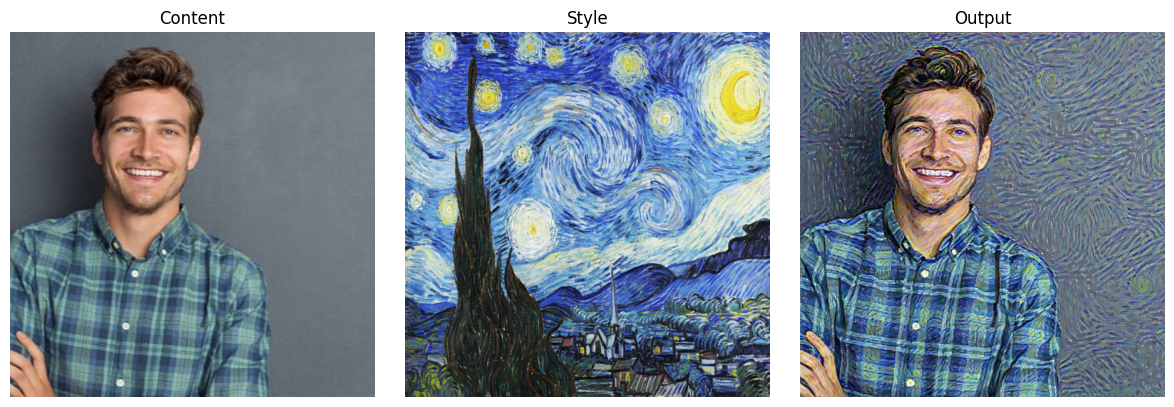

In [84]:
# Display content, style, and output side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, tensor, title in [(axes[0], content_img, "Content"), (axes[1], style_img, "Style"), (axes[2], output, "Output")]:
    img = tensor.cpu().clone().squeeze(0)
    img = transforms.ToPILImage()(img)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()